In [22]:
import sys
sys.path.insert(0, '../src')
import torch
import matplotlib.pyplot as plt
from data import *
from visualization import _color_limits
from error_computation import compute_conservation_error


from psuedo_spectral_solver_naive import ShallowWaterSolver as PSSolver
from visualization import animate_swe_on_box

## Dampe E-fold = 2 days

In [34]:
data_dir = "../solver_output/"

In [ ]:
dts = [200, 175, 150, 50]
nlats = [32, 64, 128, 256]
for i in range(4):
    dt = dts[i]
    nlat = nlats[i]
    file_name = data_dir + "naivePS7days_grid" + str(nlat)
    solver = PSSolver(dt=dt, nlat=nlat, nlon=2*nlat, lmax=int(nlat/2), mmax=int(nlat/2), damp_efold=5)
    solver.run(days=7, file_name=file_name, output_dir="../solver_output")

 Simulating SWE on Sphere for 7 days (Naive Psuedo-Spectral Solver)
 Total frames = 253 | Time per frame = 0.6666666666666666 (h)


Simulation in Progrgess: 100%|██████████| 253/253 [00:10<00:00, 24.92it/s]


Saved simulation data(metadata : dict[dt, nlat, nlon, lmax, mmax, grid, step_per_save], trajectory : tensor(torch.Size([253, 3, 32, 32]))) -> ../solver_output/../solver_output/naivePS7days_grid32
 Simulating SWE on Sphere for 7 days (Naive Psuedo-Spectral Solver)
 Total frames = 289 | Time per frame = 0.5833333333333334 (h)


Simulation in Progrgess: 100%|██████████| 289/289 [00:23<00:00, 12.37it/s]


Saved simulation data(metadata : dict[dt, nlat, nlon, lmax, mmax, grid, step_per_save], trajectory : tensor(torch.Size([289, 3, 64, 64]))) -> ../solver_output/../solver_output/naivePS7days_grid64
 Simulating SWE on Sphere for 7 days (Naive Psuedo-Spectral Solver)
 Total frames = 337 | Time per frame = 0.5 (h)


Simulation in Progrgess: 100%|██████████| 337/337 [01:53<00:00,  2.97it/s]


Saved simulation data(metadata : dict[dt, nlat, nlon, lmax, mmax, grid, step_per_save], trajectory : tensor(torch.Size([337, 3, 128, 128]))) -> ../solver_output/../solver_output/naivePS7days_grid128
 Simulating SWE on Sphere for 7 days (Naive Psuedo-Spectral Solver)
 Total frames = 1009 | Time per frame = 0.16666666666666666 (h)


Simulation in Progrgess: 100%|██████████| 1009/1009 [58:46<00:00,  3.49s/it] 


Saved simulation data(metadata : dict[dt, nlat, nlon, lmax, mmax, grid, step_per_save], trajectory : tensor(torch.Size([1009, 3, 256, 256]))) -> ../solver_output/../solver_output/naivePS7days_grid256


===== Plotting error for nlat = 32 ====== 
Returning a tuple  (X, Y, [Z_i]_i) where X=lons, Y=lats and Z is pv 
  i ⊂ [1, 253 | dt = 200] | Shape = (32, 64) 
Returning a tuple  (X, Y, [Z_i]_i) where X=lons, Y=lats and Z is h 
  i ⊂ [1, 253 | dt = 200] | Shape = (32, 64) 
===== Plotting error for nlat = 64 ====== 
Returning a tuple  (X, Y, [Z_i]_i) where X=lons, Y=lats and Z is pv 
  i ⊂ [1, 289 | dt = 175] | Shape = (64, 128) 
Returning a tuple  (X, Y, [Z_i]_i) where X=lons, Y=lats and Z is h 
  i ⊂ [1, 289 | dt = 175] | Shape = (64, 128) 
===== Plotting error for nlat = 128 ====== 
Returning a tuple  (X, Y, [Z_i]_i) where X=lons, Y=lats and Z is pv 
  i ⊂ [1, 337 | dt = 150] | Shape = (128, 256) 
Returning a tuple  (X, Y, [Z_i]_i) where X=lons, Y=lats and Z is h 
  i ⊂ [1, 337 | dt = 150] | Shape = (128, 256) 
===== Plotting error for nlat = 256 ====== 
Returning a tuple  (X, Y, [Z_i]_i) where X=lons, Y=lats and Z is pv 
  i ⊂ [1, 1009 | dt = 50] | Shape = (256, 512) 
Returning a tupl

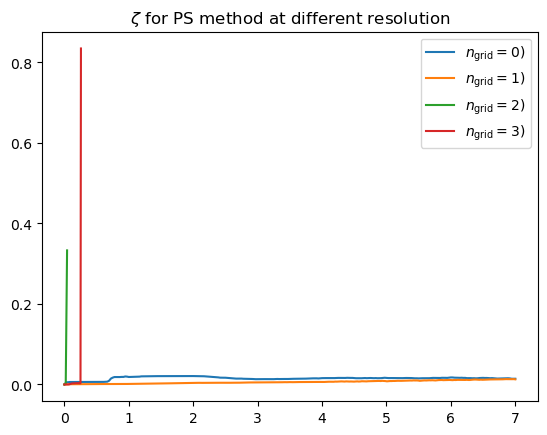

In [ ]:
dts = [200, 175, 150, 50]
nlats = [32, 64, 128, 256]
markers = ['o', 'x', '-', '.']
fig,ax = plt.subplots()
for i in range(4):
    print(f"===== Plotting error for nlat = {nlats[i]} ====== ")
    ax.set_title(r"$\epsilon$ for PS method at different resolution")
    file_name = data_dir + "naivePS7days_grid" + str(nlats[i])
    lons, lats, pv_video = get_var_field(data_path=file_name, var='pv')
    lons, lats, h_video = get_var_field(data_path=file_name, var='h')
    errors = compute_conservation_error(vort_video=pv_video, height_video=h_video, N_c=20, lats=lats)
    days = np.linspace(0, 7, num=int(7*24*3600/dts[i]/12 + 1))
    line, = ax.plot(days, errors, label=rf'$n_{{\text{{grid}}}}={nlats[i]})$', marker=markers[i])
    ax.legend()
plt.show()
    

/var/folders/rt/3dkh62n96hxd9jccg_nzsfkh0000gn/T/ipykernel_17688/1309267669.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  extent = [np.degrees(lons[0]), np.degrees(lons[-1]),
/var/folders/rt/3dkh62n96hxd9jccg_nzsfkh0000gn/T/ipykernel_17688/1309267669.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.degrees(lats[0]), np.degrees(lats[-1])]


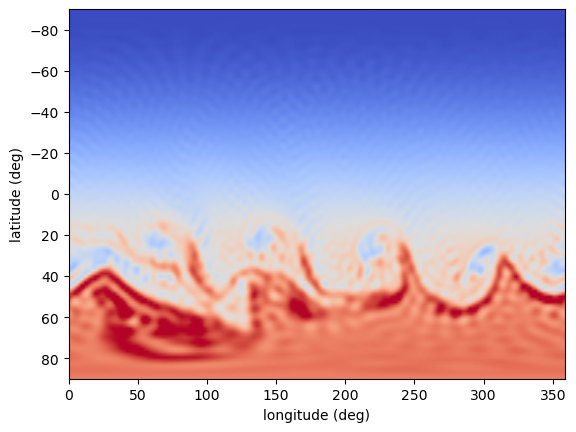

In [3]:
frame = video[-1]

vmin, vmax = _color_limits(video)
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap(name='coolwarm')
extent = [np.degrees(lons[0]), np.degrees(lons[-1]),
              np.degrees(lats[0]), np.degrees(lats[-1])]

fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.set_xlabel("longitude (deg)")
ax.set_ylabel("latitude (deg)")

# Origin "lower" so increasing latitude points up.
im = ax.imshow(frame, origin="lower", extent=extent,
                aspect="auto", norm=norm, cmap=cmap,
                interpolation="bilinear")